<a href="https://colab.research.google.com/github/DhruthiVijay/ML-LAB/blob/main/ML_LABEXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  🌳 RANDOM FOREST
Enter CSV path (default: data.csv): /content/consumer_behavior_dataset.csv
Enter target column: purchase_decision
Classification or Regression? (c/r): c
✅ Loaded: 5000 rows × 19 columns
  Encoded 'user_id'
  Encoded 'product_id'
  Encoded 'category'
  Encoded 'payment_method'
  Encoded 'purchase_date'
  Encoded 'review_text'
  Encoded 'gender'
  Encoded 'income_level'
  Encoded 'location'
  Train: 4000 | Test: 1000

Number of trees (default 100): 8

  📊 Random Forest Classifier (n=8) — Classification Results
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000


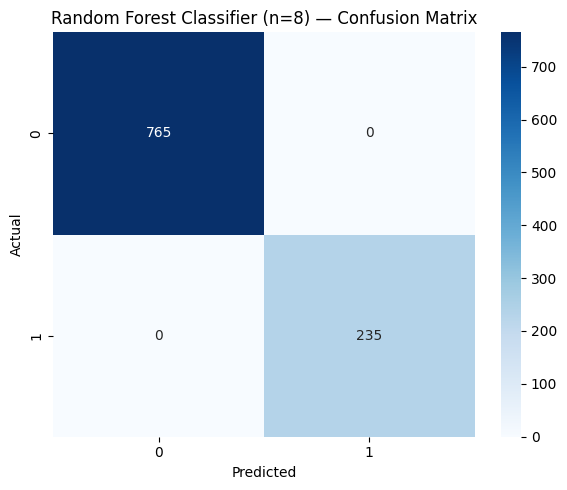

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             mean_squared_error, r2_score, mean_absolute_error)


def load_and_preprocess(path, target_col):
    df = pd.read_csv(path)
    print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"  Encoded '{col}'")
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"  Train: {X_train.shape[0]} | Test: {X_test.shape[0]}\n")
    return X_train, X_test, y_train, y_test


def evaluate_classification(y_true, y_pred, name):
    print(f"\n{'='*50}\n  📊 {name} — Classification Results\n{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()


def evaluate_regression(y_true, y_pred, name):
    print(f"\n{'='*50}\n  📈 {name} — Regression Results\n{'='*50}")
    mse = mean_squared_error(y_true, y_pred)
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {np.sqrt(mse):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, color='steelblue', edgecolors='k', alpha=0.7)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Ideal Fit')
    plt.xlabel('Actual'); plt.ylabel('Predicted')
    plt.title(f'{name} — Actual vs Predicted')
    plt.legend(); plt.tight_layout(); plt.show()


def run():
    print("\n" + "=" * 60)
    print("  🌳 RANDOM FOREST")
    print("=" * 60)
    path = input("Enter CSV path (default: data.csv): ").strip() or "data.csv"
    target = input("Enter target column: ").strip()
    mode = input("Classification or Regression? (c/r): ").strip().lower()
    X_train, X_test, y_train, y_test = load_and_preprocess(path, target)
    n = input("Number of trees (default 100): ").strip()
    n = int(n) if n else 100
    if mode == 'r':
        model = RandomForestRegressor(n_estimators=n, random_state=42)
        model.fit(X_train, y_train)
        evaluate_regression(y_test, model.predict(X_test), f"Random Forest Regressor (n={n})")
    else:
        model = RandomForestClassifier(n_estimators=n, random_state=42)
        model.fit(X_train, y_train)
        evaluate_classification(y_test, model.predict(X_test), f"Random Forest Classifier (n={n})")


if __name__ == "__main__":
    run()

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  # Added for replacement
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    file_path = "/content/consumer_behavior_dataset.csv"
    df = pd.read_csv(file_path)
    print("Successfully loaded the dataset.")
except FileNotFoundError:
    print(
        "File not found. Please upload 'consumer_behavior_dataset.csv' to the /content/ folder."
    )


target_col = [c for c in df.columns if "purchase_decision" in c.lower()][0]


le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- RANDOM FOREST PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))


# Initialized with max_iter=1000 to ensure gradient descent converges
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("\n--- LOGISTIC REGRESSION PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_preds))


Successfully loaded the dataset.

--- RANDOM FOREST PERFORMANCE ---
Accuracy: 1.0000
Confusion Matrix:
[[765   0]
 [  0 235]]

--- LOGISTIC REGRESSION PERFORMANCE ---
Accuracy: 0.9990
Confusion Matrix:
[[764   1]
 [  0 235]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
